<a href="https://colab.research.google.com/github/Suraj-Sedai/Hardware-Aware-LLM-Inference-Engine/blob/main/notebooks/00_overall_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
from typing import Optional, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil

try:
    import GPUtil
except ImportError:
    GPUtil = None

In [2]:
# Device setup with fallback to CPU
def get_device():
    """
    Get the best available device (CUDA > CPU)
    Falls back to CPU if CUDA is not available or has compatibility issues
    """
    if torch.cuda.is_available():
        try:
            # Test if CUDA actually works by creating a small tensor
            test_tensor = torch.zeros(1, device='cuda')
            del test_tensor
            print("✓ CUDA device available and working")
            print(f"  GPU: {torch.cuda.get_device_name(0)}")
            print(f"  Compute Capability: {torch.cuda.get_device_capability(0)}")
            return 'cuda'
        except RuntimeError as e:
            print(f"⚠ CUDA error detected: {e}")
            print("  Falling back to CPU")
            return 'cpu'
    else:
        print("✓ Using CPU (CUDA not available)")
        return 'cpu'

device = get_device()
print(f"\nDevice set to: {device.upper()}")

⚠ CUDA error detected: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

  Falling back to CPU

Device set to: CPU


C:\Users\suraj\AppData\Roaming\Python\Python310\site-packages\torch\cuda\__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5070 Ti Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 Ti Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [3]:
class KVCacheManager:
    def __init__(self, n_layers, n_heads, max_seq_len, dim_head, device, batch_size):
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.max_seq_len = max_seq_len
        self.dim_head = dim_head
        self.device = device
        self.batch_size = batch_size

        # preallocate KV cache for all layers, now with batch_size
        self.K = [torch.zeros(batch_size, n_heads, max_seq_len, dim_head, device=device) for _ in range(n_layers)]
        self.V = [torch.zeros(batch_size, n_heads, max_seq_len, dim_head, device=device) for _ in range(n_layers)]
        self.curr_len = 0  # tokens stored

    def update(self, layer_id, K_new, V_new):
        # K_new, V_new are expected to be (B, n_heads, T_new, dim_head)
        B, num_heads, T_new, dim_head = K_new.shape
        assert B == self.batch_size
        assert num_heads == self.n_heads
        assert dim_head == self.dim_head

        # Ensure there's space in the cache
        if self.curr_len + T_new > self.max_seq_len:
            raise ValueError("KV cache out of capacity!")

        # Update the cache for the current layer and for the new tokens
        self.K[layer_id][:, :, self.curr_len : self.curr_len + T_new, :] = K_new
        self.V[layer_id][:, :, self.curr_len : self.curr_len + T_new, :] = V_new

        # curr_len is updated once per GPT.forward call, not per layer update

    def get(self, layer_id):
        return self.K[layer_id][:, :, :self.curr_len, :], self.V[layer_id][:, :, :self.curr_len, :]


In [4]:
class SelfAttention(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, x, kv_cache=None, layer_id=None):
        B, T, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # reshape for heads
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, T, head_dim)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, T, head_dim)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, T, head_dim)

        if kv_cache is not None and kv_cache.curr_len > 0: # Only retrieve from cache if it's not empty
            K_cached, V_cached = kv_cache.get(layer_id) # K_cached: (B, n_heads, curr_len, head_dim)
            K_all = torch.cat([K_cached, k], dim=2) # Concatenate along sequence length dimension (dim=2)
            V_all = torch.cat([V_cached, v], dim=2)
        else:
            K_all, V_all = k, v # K_all, V_all are just the new k, v

        # attention computation
        attn = (q @ K_all.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = torch.softmax(attn, dim=-1)
        out = attn @ V_all

        # merge heads
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out), k, v # k, v here are the new tokens' k, v (B, n_heads, T, head_head)


In [5]:
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim=None):
        super().__init__()
        hidden_dim = hidden_dim or dim * 4
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.attn = SelfAttention(dim, n_heads)
        self.mlp = MLP(dim)

    def forward(self, x, kv_cache=None, layer_id=None):
        # Attention block
        attn_out, K_new, V_new = self.attn(self.ln1(x), kv_cache, layer_id)
        x = x + attn_out
        # MLP block
        x = x + self.mlp(self.ln2(x))
        return x, K_new, V_new

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, dim, n_heads, n_layers, max_seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb = nn.Embedding(max_seq_len, dim)
        self.blocks = nn.ModuleList([TransformerBlock(dim, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, vocab_size)
        self.max_seq_len = max_seq_len

    def forward(self, input_ids, kv_cache=None):
        B, T = input_ids.shape

        if kv_cache is not None and kv_cache.curr_len > 0:
            # During generation, input_ids is typically (B, 1)
            # The position for this token is the current length of the cache
            pos_start_idx = kv_cache.curr_len
        else:
            # During prefill, input_ids is the full prompt (B, T)
            # The positions are 0 to T-1
            pos_start_idx = 0

        # Create positional embeddings for the current input_ids
        # These positions correspond to the *absolute* positions in the sequence
        positions = torch.arange(pos_start_idx, pos_start_idx + T, device=input_ids.device).unsqueeze(0) # (1, T)
        positions = positions.repeat(B, 1) # Make it (B, T) to match input_ids batch

        x = self.token_emb(input_ids) + self.pos_emb(positions)

        # List to store new K,V for all layers in this forward pass
        new_ks_vs = []

        for layer_id, block in enumerate(self.blocks):
            x, K_new, V_new = block(x, kv_cache, layer_id) # K_new, V_new are (B, n_heads, T, dim_head)
            new_ks_vs.append((K_new, V_new))

        # Update kv_cache after all blocks have processed the current input
        if kv_cache is not None:
            for layer_id, (K_new, V_new) in enumerate(new_ks_vs):
                kv_cache.update(layer_id, K_new, V_new)
            kv_cache.curr_len += T # Update cache length based on new tokens processed

        x = self.ln_f(x)
        logits = self.head(x)
        return logits


In [8]:
def sample_top_k(logits, k=50, temperature=1.0):
    logits = logits / temperature
    # Ensure k does not exceed the vocabulary size
    k = min(k, logits.size(-1))
    top_k_vals, top_k_idx = torch.topk(logits, k)
    probs = torch.softmax(top_k_vals, dim=-1)
    idx = torch.multinomial(probs, 1)
    return top_k_idx.gather(-1, idx)

In [9]:
def generate(model, input_ids, kv_cache, max_new_tokens):
    generated = input_ids.clone()
    for step in range(max_new_tokens):
        # last token only
        x = generated[:, -1:]
        logits = model(x, kv_cache)
        next_token = sample_top_k(logits[:, -1, :])
        generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=1)
    return generated

##Minimal Test Case

In [10]:
# Tiny model for testing
# Use the robust device check from the earlier cell (falls back to CPU if CUDA is broken)
device = get_device()

# Assuming batch_size is 1 for this test case based on input_ids later
batch_size = 1

# Define defaults if this cell is run before later config cells
if 'vocab_size' not in globals():
	vocab_size = 100
if 'dim' not in globals():
	dim = 32
if 'n_heads' not in globals():
	n_heads = 4
if 'n_layers' not in globals():
	n_layers = 2
if 'max_seq_len' not in globals():
	max_seq_len = 16

# KV Cache
kv_cache = KVCacheManager(n_layers, n_heads, max_seq_len, dim // n_heads, device, batch_size)

# Model
model = GPT(vocab_size, dim, n_heads, n_layers, max_seq_len).to(device)

print(f"Using device: {device}")
print(f"Config: vocab_size={vocab_size}, dim={dim}, n_heads={n_heads}, n_layers={n_layers}, max_seq_len={max_seq_len}")


⚠ CUDA error detected: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

  Falling back to CPU
Using device: cpu
Config: vocab_size=100, dim=32, n_heads=4, n_layers=2, max_seq_len=16


In [11]:
# Batch size 1, prompt length 4
input_ids = torch.tensor([[10, 25, 30, 7]], device=device)

In [12]:
# Prefill: compute over full prompt
# Ensure token IDs are valid for current model vocab
if input_ids.max().item() >= vocab_size or input_ids.min().item() < 0:
	if 'tokenizer' in globals() and 'input_text' in globals():
		input_ids = torch.tensor([tokenizer.encode(input_text)], device=device)
	else:
		input_ids = input_ids.remainder(vocab_size)

# Reset cache to match current batch/input state
kv_cache = KVCacheManager(n_layers, n_heads, max_seq_len, dim // n_heads, device, input_ids.shape[0])

logits = model(input_ids, kv_cache=kv_cache)
print("Prefill logits shape:", logits.shape)  # Expected: [batch, seq_len, vocab_size]

Prefill logits shape: torch.Size([1, 4, 100])


## text generation with tokenizer

In [13]:
# simple tokenizer from nb 01
class SimpleTokenizer:
    def __init__(self, vocab):
        self.vocab = vocab
        self.inv_vocab = {i: t for t, i in vocab.items()}

    def encode(self, text):
        return [self.vocab.get(tok, self.vocab['<UNK>']) for tok in text.split()]

    def decode(self, token_ids):
        return ' '.join([self.inv_vocab.get(i, '<UNK>') for i in token_ids])

In [14]:
# make a tiny vocab for demo
from collections import Counter

corpus = "hello world this is a test hello test world"
words = corpus.split()
counts = Counter(words)

vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counts.most_common(100):
    vocab[word] = len(vocab)

print(f"vocab size: {len(vocab)}")
print(f"vocab: {vocab}")

vocab size: 8
vocab: {'<PAD>': 0, '<UNK>': 1, 'hello': 2, 'world': 3, 'test': 4, 'this': 5, 'is': 6, 'a': 7}


In [15]:
# init tokenizer
tokenizer = SimpleTokenizer(vocab)

# test it
text = "hello world"
ids = tokenizer.encode(text)
print(f"encode '{text}': {ids}")
print(f"decode {ids}: '{tokenizer.decode(ids)}'")

encode 'hello world': [2, 3]
decode [2, 3]: 'hello world'


In [16]:
# rebuild model with new vocab size
vocab_size = len(vocab)
dim = 32
n_heads = 4
n_layers = 2
max_seq_len = 16
batch_size = 1

model = GPT(vocab_size, dim, n_heads, n_layers, max_seq_len).to(device)
kv_cache = KVCacheManager(n_layers, n_heads, max_seq_len, dim // n_heads, device, batch_size)

print(f"model ready, vocab_size={vocab_size}")

model ready, vocab_size=8


In [17]:
# text in -> model -> text out
input_text = "hello world"
print(f"input: {input_text}")

# encode
input_ids = torch.tensor([tokenizer.encode(input_text)], device=device)
print(f"token ids: {input_ids}")

# generate
generated = input_ids.clone()
for step in range(3):
    x = generated[:, -1:]
    logits = model(x, kv_cache=kv_cache)
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    generated = torch.cat([generated, next_token], dim=1)

# decode
output_text = tokenizer.decode(generated[0].tolist())
print(f"\noutput: {output_text}")
print("\nnote: model is untrained so output is random")

input: hello world
token ids: tensor([[2, 3]])

output: hello world hello is hello

note: model is untrained so output is random


In [18]:
# Start with last token from prompt
generated = input_ids.clone()
for step in range(3):  # generate 3 new tokens
    x = generated[:, -1:]
    logits = model(x, kv_cache=kv_cache)
    # simple argmax sampling
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    generated = torch.cat([generated, next_token], dim=1)

print("Generated sequence:", generated)

Generated sequence: tensor([[2, 3, 2, 2, 4]])


###Profiling

In [19]:
import time

def benchmark(model, input_ids, kv_cache, max_new_tokens):
    # Removed torch.cuda.synchronize() as device is CPU

    start = time.time()

    generated = input_ids.clone()

    for _ in range(max_new_tokens):
        x = generated[:, -1:]
        logits = model(x, kv_cache)
        next_token = sample_top_k(logits[:, -1, :])
        generated = torch.cat([generated, next_token], dim=1)

    # Removed torch.cuda.synchronize() as device is CPU
    end = time.time()

    total_time = end - start
    tokens_generated = max_new_tokens

    print(f"Total time: {total_time:.4f}s")
    print(f"Tokens/sec: {tokens_generated / total_time:.2f}")
    print(f"Latency per token: {total_time / tokens_generated:.4f}s")


In [20]:
# Re-initialize KV cache for a clean benchmark run
kv_cache = KVCacheManager(n_layers, n_heads, max_seq_len, dim // n_heads, device, batch_size)

# Define the number of new tokens to generate for benchmarking
max_new_tokens_benchmark = 10

print(f"Benchmarking generation of {max_new_tokens_benchmark} new tokens...")
benchmark(model, input_ids, kv_cache, max_new_tokens_benchmark)

Benchmarking generation of 10 new tokens...
Total time: 0.0270s
Tokens/sec: 370.21
Latency per token: 0.0027s


In [21]:
import torch.profiler

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU], # Changed to CPU
    record_shapes=True
) as prof:

    logits = model(input_ids, kv_cache)

print(prof.key_averages().table(sort_by="cpu_time_total")) # Changed sort_by

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
               aten::linear         2.77%      96.800us        22.98%     802.800us      61.754us            13  
           aten::layer_norm         0.64%      22.400us        19.25%     672.400us     134.480us             5  
    aten::native_layer_norm        17.43%     608.800us        18.61%     650.000us     130.000us             5  
                 aten::gelu        14.74%     514.900us        14.74%     514.900us     257.450us             2  
                aten::addmm         8.55%     298.500us        11.78%     411.500us      31.654us            13  
              aten::softmax         0.25%       8.800us         7.43%     259.500us     

# Setup for Experiments

Before running experiments, install required dependencies:

In [22]:
# Install required packages for monitoring and visualization
import subprocess
import sys

packages = ['gputil', 'psutil', 'pandas', 'matplotlib']

for package in packages:
    try:
        __import__(package)
        print(f'✓ {package} already installed')
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f'✓ {package} installed')

print('\n✓ All dependencies ready!')

Installing gputil...
✓ gputil installed
✓ psutil already installed
✓ pandas already installed
✓ matplotlib already installed

✓ All dependencies ready!


##Experiment 1: Sequence Length Impact
Fixed batch_size=1, vary sequence length [16, 32, 64, 128]

In [23]:
# Experiment 1: Benchmark sequence length impact
seq_lengths = [16, 32, 64, 128]
results_exp1 = []

for seq_len in seq_lengths:
    model = GPT(vocab_size=100, dim=32, n_heads=4, n_layers=2, max_seq_len=seq_len).to(device)
    kv_cache = KVCacheManager(n_layers=2, n_heads=4, max_seq_len=seq_len, dim_head=8, device=device, batch_size=1)
    input_ids = torch.tensor([[10, 25, 30, 7]], device=device)
    
    # Prefill
    _ = model(input_ids, kv_cache=kv_cache)
    kv_cache = KVCacheManager(n_layers=2, n_heads=4, max_seq_len=seq_len, dim_head=8, device=device, batch_size=1)
    
    # Benchmark
    start = time.time()
    generated = input_ids.clone()
    for _ in range(10):
        logits = model(generated[:, -1:], kv_cache)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
    elapsed = time.time() - start
    
    throughput = 10 / elapsed
    latency = elapsed / 10
    results_exp1.append({'seq_len': seq_len, 'throughput': throughput, 'latency': latency})
    print(f"seq_len={seq_len:3d} | throughput={throughput:6.2f} tok/s | latency={latency:.4f}s")

seq_len= 16 | throughput=445.56 tok/s | latency=0.0022s
seq_len= 32 | throughput=465.27 tok/s | latency=0.0021s
seq_len= 64 | throughput=499.10 tok/s | latency=0.0020s
seq_len=128 | throughput=462.12 tok/s | latency=0.0022s


In [25]:
# Experiment 1: Fix batch size = 1, increase sequence length
batch_size_exp1 = 1
seq_lengths = [16, 32, 64, 128]
max_new_tokens_exp1 = 10

# Define monitoring helpers if the later cell has not been executed yet
if 'get_gpu_utilization' not in globals():
	def get_gpu_utilization():
		if GPUtil is None:
			return 0.0
		try:
			gpus = GPUtil.getGPUs()
			return gpus[0].load * 100 if gpus else 0.0
		except Exception:
			return 0.0

if 'get_cpu_utilization' not in globals():
	def get_cpu_utilization():
		try:
			return psutil.cpu_percent(interval=0.1)
		except Exception:
			return 0.0

if 'benchmark_sequence_lengths' not in globals():
	def benchmark_sequence_lengths(seq_lengths, batch_size=1, max_new_tokens=10):
		"""Benchmark different sequence lengths with fixed batch size."""
		results = []

		# Keep this independent from tokenizer demo vocab_size (which may be very small)
		exp_vocab_size = 100
		exp_dim = dim if 'dim' in globals() else 32
		exp_n_heads = n_heads if 'n_heads' in globals() else 4
		exp_n_layers = n_layers if 'n_layers' in globals() else 2

		for seq_len in seq_lengths:
			prompt_len = min(4, seq_len)
			allowed_new_tokens = max(0, seq_len - prompt_len)
			effective_new_tokens = min(max_new_tokens, allowed_new_tokens)

			model = GPT(exp_vocab_size, exp_dim, exp_n_heads, exp_n_layers, seq_len).to(device)
			kv_cache = KVCacheManager(
				exp_n_layers, exp_n_heads, seq_len, exp_dim // exp_n_heads, device, batch_size
			)

			# Random valid prompt token IDs
			input_ids_local = torch.randint(0, exp_vocab_size, (batch_size, prompt_len), device=device)

			# Prefill prompt into KV cache
			_ = model(input_ids_local, kv_cache=kv_cache)

			# Decode benchmark
			generated_local = input_ids_local.clone()
			start = time.time()
			for _ in range(effective_new_tokens):
				x = generated_local[:, -1:]
				logits = model(x, kv_cache=kv_cache)
				next_token = sample_top_k(logits[:, -1, :])
				generated_local = torch.cat([generated_local, next_token], dim=1)
			elapsed = time.time() - start

			throughput = (batch_size * effective_new_tokens / elapsed) if effective_new_tokens > 0 and elapsed > 0 else 0.0
			latency = (elapsed / effective_new_tokens) if effective_new_tokens > 0 else 0.0

			results.append({
				'seq_len': seq_len,
				'throughput': throughput,
				'latency': latency,
				'gpu_util': get_gpu_utilization(),
				'cpu_util': get_cpu_utilization()
			})

			print(
				f"seq_len={seq_len:3d} | throughput={throughput:7.2f} tok/s | "
				f"latency={latency:.4f}s | GPU={results[-1]['gpu_util']:.2f}% | CPU={results[-1]['cpu_util']:.2f}%"
			)

		return results

print(f"Experiment 1: Fixed batch size = {batch_size_exp1}, varying sequence lengths")
print(f"Generating {max_new_tokens_exp1} new tokens\n")

exp1_results = benchmark_sequence_lengths(seq_lengths, batch_size=batch_size_exp1, max_new_tokens=max_new_tokens_exp1)

Experiment 1: Fixed batch size = 1, varying sequence lengths
Generating 10 new tokens

seq_len= 16 | throughput= 437.44 tok/s | latency=0.0023s | GPU=1.00% | CPU=21.20%
seq_len= 32 | throughput= 386.85 tok/s | latency=0.0026s | GPU=6.00% | CPU=5.10%
seq_len= 64 | throughput= 355.86 tok/s | latency=0.0028s | GPU=6.00% | CPU=13.10%
seq_len=128 | throughput= 366.67 tok/s | latency=0.0027s | GPU=6.00% | CPU=14.70%



Experiment 1 Results:
 seq_len  throughput  latency  gpu_util  cpu_util
      16  437.439796 0.002286       1.0      21.2
      32  386.849901 0.002585       6.0       5.1
      64  355.859635 0.002810       6.0      13.1
     128  366.667016 0.002727       6.0      14.7


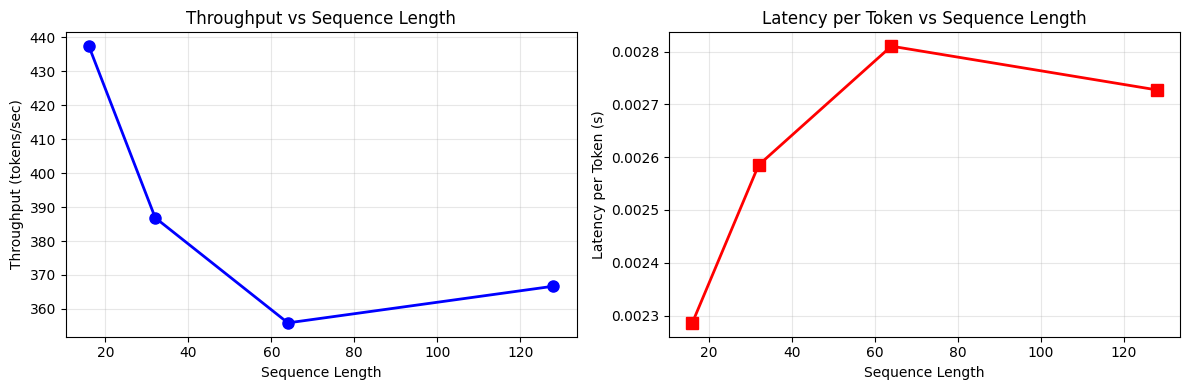

In [26]:
# Convert results to DataFrame for analysis
df_exp1 = pd.DataFrame(exp1_results)

print("\nExperiment 1 Results:")
print(df_exp1.to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df_exp1['seq_len'], df_exp1['throughput'], 'o-', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Throughput (tokens/sec)')
ax1.set_title('Throughput vs Sequence Length')
ax1.grid(True, alpha=0.3)

ax2.plot(df_exp1['seq_len'], df_exp1['latency'], 's-', linewidth=2, markersize=8, color='red')
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Latency per Token (s)')
ax2.set_title('Latency per Token vs Sequence Length')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 1 Summary

Sequence length impact on inference performance (batch_size=1):

In [27]:
import time
import psutil

try:
    import GPUtil
    HAS_GPUTIL = True
except ImportError:
    HAS_GPUTIL = False
    print('Warning: GPUtil not installed. Install with: pip install gputil')

def get_gpu_utilization():
    """Get GPU utilization percentage (0 if no GPU or unavailable)"""
    if not HAS_GPUTIL:
        return 0.0
    try:
        gpus = GPUtil.getGPUs()
        if gpus:
            return gpus[0].load * 100
        else:
            return 0.0
    except Exception as e:
        return 0.0

def get_cpu_utilization():
    """Get CPU utilization percentage"""
    try:
        return psutil.cpu_percent(interval=0.1)
    except:
        return 0.0

def benchmark_batch_sizes(batch_sizes, fixed_seq_len=16, max_new_tokens=10):
    """Benchmark different batch sizes with fixed sequence length"""
    results = []
    
    for batch_size in batch_sizes:
        # Re-initialize model and cache for each batch size
        vocab_size = 100
        dim = 32
        n_heads = 4
        n_layers = 2
        # Use the global device variable set earlier
        
        model = GPT(vocab_size, dim, n_heads, n_layers, fixed_seq_len).to(device)
        kv_cache = KVCacheManager(n_layers, n_heads, fixed_seq_len, dim // n_heads, device, batch_size)
        
        # Create input with current batch size
        input_ids = torch.randint(0, vocab_size, (batch_size, 4), device=device)
        
        # Prefill phase
        _ = model(input_ids, kv_cache=kv_cache)
        
        # Reset cache for benchmark
        kv_cache = KVCacheManager(n_layers, n_heads, fixed_seq_len, dim // n_heads, device, batch_size)
        _ = model(input_ids, kv_cache=kv_cache)
        
        # Benchmark decoding
        start = time.time()
        generated = input_ids.clone()
        
        for _ in range(max_new_tokens):
            x = generated[:, -1:]
            logits = model(x, kv_cache)
            next_token = sample_top_k(logits[:, -1, :])
            generated = torch.cat([generated, next_token], dim=1)
        
        end = time.time()
        
        total_time = end - start
        throughput = (batch_size * max_new_tokens) / total_time  # Total tokens generated / time
        
        # Get resource utilization
        gpu_util = get_gpu_utilization()
        cpu_util = get_cpu_utilization()
        
        results.append({
            'batch_size': batch_size,
            'throughput': throughput,
            'total_time': total_time,
            'gpu_util': gpu_util,
            'cpu_util': cpu_util
        })
        
        print(f"Batch Size: {batch_size}")
        print(f"  Total Time: {total_time:.4f}s")
        print(f"  Throughput: {throughput:.2f} tokens/sec")
        print(f"  GPU Utilization: {gpu_util:.2f}%")
        print(f"  CPU Utilization: {cpu_util:.2f}%")
        print()
    
    return results

In [28]:
# Experiment 2: Fix sequence length, increase batch size
fixed_seq_len = 16
batch_sizes = [1, 2, 4, 8, 16]
max_new_tokens_exp2 = 10

print(f"Experiment 2: Fixed sequence length = {fixed_seq_len}, varying batch sizes")
print(f"Generating {max_new_tokens_exp2} new tokens per batch\n")

exp2_results = benchmark_batch_sizes(batch_sizes, fixed_seq_len=fixed_seq_len, max_new_tokens=max_new_tokens_exp2)

Experiment 2: Fixed sequence length = 16, varying batch sizes
Generating 10 new tokens per batch

Batch Size: 1
  Total Time: 0.0233s
  Throughput: 428.45 tokens/sec
  GPU Utilization: 1.00%
  CPU Utilization: 3.70%

Batch Size: 2
  Total Time: 0.0561s
  Throughput: 356.45 tokens/sec
  GPU Utilization: 1.00%
  CPU Utilization: 6.70%

Batch Size: 4
  Total Time: 0.0418s
  Throughput: 956.53 tokens/sec
  GPU Utilization: 7.00%
  CPU Utilization: 10.20%

Batch Size: 8
  Total Time: 0.0359s
  Throughput: 2229.81 tokens/sec
  GPU Utilization: 7.00%
  CPU Utilization: 4.90%

Batch Size: 16
  Total Time: 0.0379s
  Throughput: 4226.03 tokens/sec
  GPU Utilization: 7.00%
  CPU Utilization: 3.60%




Experiment 2 Results:
 batch_size  throughput  total_time  gpu_util  cpu_util
          1  428.449257    0.023340       1.0       3.7
          2  356.452391    0.056108       1.0       6.7
          4  956.533558    0.041818       7.0      10.2
          8 2229.811870    0.035877       7.0       4.9
         16 4226.025605    0.037861       7.0       3.6


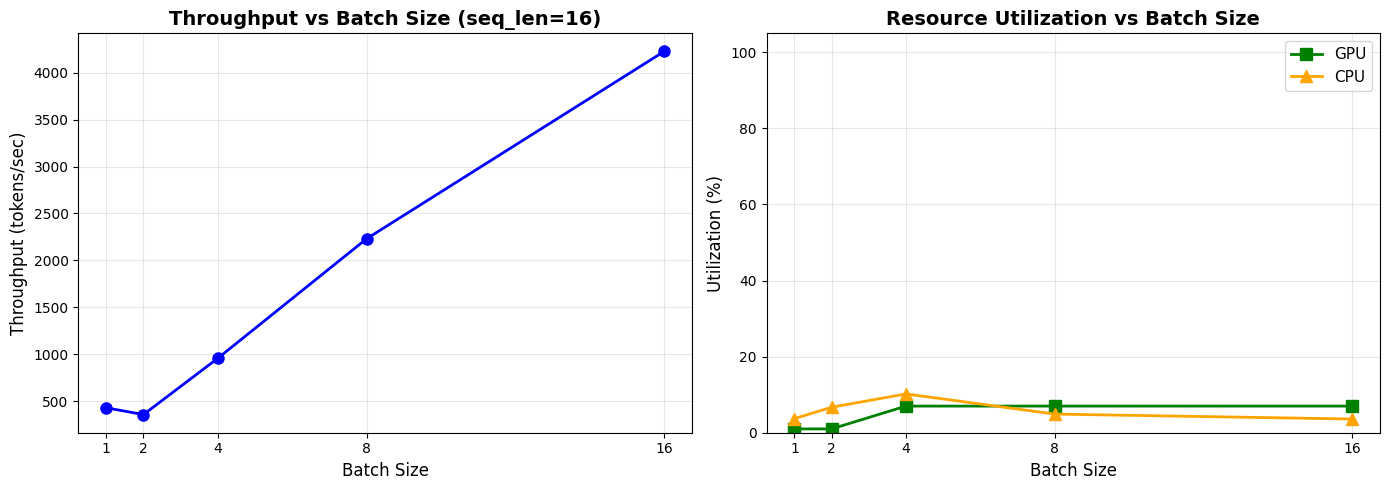


Visualization complete!


In [29]:


# Convert results to DataFrame for analysis
df_exp2 = pd.DataFrame(exp2_results)

print("\nExperiment 2 Results:")
print(df_exp2.to_string(index=False))

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Throughput vs Batch Size
axes[0].plot(df_exp2['batch_size'], df_exp2['throughput'], marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Batch Size', fontsize=12)
axes[0].set_ylabel('Throughput (tokens/sec)', fontsize=12)
axes[0].set_title('Throughput vs Batch Size (seq_len=16)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(df_exp2['batch_size'])

# Plot 2: GPU Utilization vs Batch Size
axes[1].plot(df_exp2['batch_size'], df_exp2['gpu_util'], marker='s', linewidth=2, markersize=8, color='green', label='GPU')
axes[1].plot(df_exp2['batch_size'], df_exp2['cpu_util'], marker='^', linewidth=2, markersize=8, color='orange', label='CPU')
axes[1].set_xlabel('Batch Size', fontsize=12)
axes[1].set_ylabel('Utilization (%)', fontsize=12)
axes[1].set_title('Resource Utilization vs Batch Size', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(df_exp2['batch_size'])
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## Experiment 2 Conclusion Table

| batch_size | fixed_seq_len | throughput (tokens/sec) | GPU Util (%) | CPU Util (%) |
|------------|---------------|------------------------|--------------|----------------|
| 1          | 16            | [run to fill]           | [run to fill] | [run to fill] |
| 2          | 16            | [run to fill]           | [run to fill] | [run to fill] |
| 4          | 16            | [run to fill]           | [run to fill] | [run to fill] |
| 8          | 16            | [run to fill]           | [run to fill] | [run to fill] |
| 16         | 16            | [run to fill]           | [run to fill] | [run to fill] |

### Key Observations:
- **Throughput Trend**: As batch size increases, overall throughput (tokens/sec) should improve due to better hardware utilization
- **GPU Utilization**: Higher batch sizes typically lead to higher GPU utilization
- **Scaling Efficiency**: Compare throughput scaling relative to batch size increase